In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

# (i)  READ THE TRANSACTIONAL DATASET
df = pd.read_csv('market_basket_dataset.csv')
print(" Dataset Loaded\n")
print(df.head(15).to_string(index=False))
print(f"\n  Total Transactions : {len(df)}")

 Dataset Loaded

 TransactionID                          Items
             1                   Honey,Yogurt
             2    Bread,Butter,Eggs,Jam,Pasta
             3              Coffee,Milk,Sugar
             4                   Honey,Yogurt
             5        Bread,Cheese,Milk,Pasta
             6             Biscuits,Sugar,Tea
             7                   Bread,Cheese
             8             Butter,Eggs,Yogurt
             9 Biscuits,Eggs,Honey,Tea,Yogurt
            10              Cereal,Honey,Milk
            11            Cereal,Juice,Yogurt
            12      Butter,Cheese,Coffee,Milk
            13  Biscuits,Milk,Pasta,Sugar,Tea
            14                    Coffee,Milk
            15   Biscuits,Bread,Butter,Cheese

  Total Transactions : 200


In [3]:
# (ii)  CONVERT DATASET INTO SUITABLE FORMAT
# Parse comma-separated items into lists
transactions = [set(row.split(',')) for row in df['Items']]
# Collect all unique items
all_items = sorted(set(item for t in transactions for item in t))
print("Converted to Transaction Format")
print(f"\n  Unique Items ({len(all_items)}): {all_items}")
print(f"\n  Sample Transactions (first 5):")
for i, t in enumerate(transactions[:5], 1):
    print(f"    T{i:>3}: {sorted(t)}")
# Item Frequency (how often each item appears)
item_freq = defaultdict(int)
for t in transactions:
    for item in t:
        item_freq[item] += 1
print(f"\n  Item Frequencies:")
print(f"  {'Item':<15} {'Count':>8} {'Support':>10}")
print("  " + "-" * 36)
n = len(transactions)
for item in sorted(all_items):
    sup = item_freq[item] / n
    bar = '' * int(sup * 30)
    print(f"  {item:<15} {item_freq[item]:>8}  {sup:>8.3f}   {bar}")

Converted to Transaction Format

  Unique Items (15): ['Biscuits', 'Bread', 'Butter', 'Cereal', 'Cheese', 'Coffee', 'Eggs', 'Honey', 'Jam', 'Juice', 'Milk', 'Pasta', 'Sugar', 'Tea', 'Yogurt']

  Sample Transactions (first 5):
    T  1: ['Honey', 'Yogurt']
    T  2: ['Bread', 'Butter', 'Eggs', 'Jam', 'Pasta']
    T  3: ['Coffee', 'Milk', 'Sugar']
    T  4: ['Honey', 'Yogurt']
    T  5: ['Bread', 'Cheese', 'Milk', 'Pasta']

  Item Frequencies:
  Item               Count    Support
  ------------------------------------
  Biscuits              50     0.250   
  Bread                 56     0.280   
  Butter                76     0.380   
  Cereal                48     0.240   
  Cheese                47     0.235   
  Coffee                41     0.205   
  Eggs                  54     0.270   
  Honey                 44     0.220   
  Jam                   27     0.135   
  Juice                 37     0.185   
  Milk                  72     0.360   
  Pasta                 34     0.170 

In [7]:
#  APRIORI ALGORITHM — implemented from scratch
def get_support(itemset, transactions):
    """Count how many transactions contain all items in itemset."""
    count = sum(1 for t in transactions if itemset.issubset(t))
    return count / len(transactions)
def apriori(transactions, min_support, min_confidence):
    """
    Full Apriori Algorithm:
    1. Find frequent 1-itemsets
    2. Generate candidate k-itemsets from frequent (k-1)-itemsets
    3. Prune candidates below min_support
    4. Repeat until no new frequent itemsets
    5. Generate association rules from frequent itemsets
    """
    n = len(transactions)
    all_items = sorted(set(item for t in transactions for item in t))

    # Step 1: Frequent 1-itemsets 
    freq_itemsets = {}   # {frozenset: support}

    L1 = {}
    for item in all_items:
        fs  = frozenset([item])
        sup = get_support(fs, transactions)
        if sup >= min_support:
            L1[fs] = sup

    freq_itemsets.update(L1)
    current_L = L1
    k = 2

    # -Steps 2: Generate larger frequent itemsets 
    while current_L:
        # Candidate generation: join step
        prev_items = [list(fs) for fs in current_L]
        candidates = set()
        for i in range(len(prev_items)):
            for j in range(i + 1, len(prev_items)):
                union = frozenset(prev_items[i]) | frozenset(prev_items[j])
                if len(union) == k:
                    candidates.add(union)

        # Prune candidates below min_support
        Lk = {}
        for c in candidates:
            sup = get_support(c, transactions)
            if sup >= min_support:
                Lk[c] = sup

        freq_itemsets.update(Lk)
        current_L = Lk
        k += 1

    # Step 5: Generate Association Rules 
    rules = []
    for itemset, sup in freq_itemsets.items():
        if len(itemset) < 2:
            continue
        items_list = list(itemset)
        # Try all non-empty proper subsets as antecedent
        for r in range(1, len(items_list)):
            for antecedent in combinations(items_list, r):
                antecedent  = frozenset(antecedent)
                consequent  = itemset - antecedent
                ant_support = freq_itemsets.get(antecedent,
                              get_support(antecedent, transactions))
                if ant_support == 0:
                    continue
                confidence = sup / ant_support
                if confidence >= min_confidence:
                    lift = confidence / freq_itemsets.get(
                           consequent, get_support(consequent, transactions))
                    rules.append({
                        'antecedent' : set(antecedent),
                        'consequent' : set(consequent),
                        'support'    : round(sup, 4),
                        'confidence' : round(confidence, 4),
                        'lift'       : round(lift, 4)
                    })

    return freq_itemsets, rules

# (iii)  APPLY APRIORI — find frequent itemsets
MIN_SUPPORT    = 0.10     # item must appear in ≥10% of transactions
MIN_CONFIDENCE = 0.50     # rule must be correct ≥50% of the time
print(" Applying Apriori Algorithm")
print(f"\n  Minimum Support    : {MIN_SUPPORT}  ({MIN_SUPPORT*100:.0f}%)")
print(f"  Minimum Confidence : {MIN_CONFIDENCE}  ({MIN_CONFIDENCE*100:.0f}%)")
print(f"  Total Transactions : {n}")
freq_itemsets, rules = apriori(transactions, MIN_SUPPORT, MIN_CONFIDENCE)

# Separate by size
fi_1 = {k: v for k, v in freq_itemsets.items() if len(k) == 1}
fi_2 = {k: v for k, v in freq_itemsets.items() if len(k) == 2}
fi_3 = {k: v for k, v in freq_itemsets.items() if len(k) == 3}
print(f"\n  Frequent 1-itemsets : {len(fi_1)}")
print(f"  Frequent 2-itemsets : {len(fi_2)}")
print(f"  Frequent 3-itemsets : {len(fi_3)}")
print(f"  Total frequent sets : {len(freq_itemsets)}")

 Applying Apriori Algorithm

  Minimum Support    : 0.1  (10%)
  Minimum Confidence : 0.5  (50%)
  Total Transactions : 200

  Frequent 1-itemsets : 15
  Frequent 2-itemsets : 13
  Frequent 3-itemsets : 2
  Total frequent sets : 30


In [8]:
# (iv) & (v)  DISPLAY FREQUENT ITEMSETS and ASSOCIATION RULES
print(" Frequent Itemsets with Support")
# Sort by support descending
sorted_fi = sorted(freq_itemsets.items(), key=lambda x: -x[1])

print(f"\n  {'Itemset':<35} {'Support':>10} {'Count':>7}")
print("  " + "-" * 55)
for fs, sup in sorted_fi:
    items_str = '{' + ', '.join(sorted(fs)) + '}'
    count = int(sup * n)
    print(f"  {items_str:<35} {sup:>10.4f} {count:>7}")


print("(v) Association Rules")

if not rules:
    print("\n  No rules found. Try lowering min_support or min_confidence.")
else:
    # Sort by lift descending
    rules_sorted = sorted(rules, key=lambda x: -x['lift'])
    print(f"\n  Total Rules Found : {len(rules_sorted)}\n")
    print(f"  {'Rule':<42} {'Supp':>7} {'Conf':>7} {'Lift':>7}")
    print("  " + "-" * 68)
    for r in rules_sorted:
        lhs = '{' + ', '.join(sorted(r['antecedent'])) + '}'
        rhs = '{' + ', '.join(sorted(r['consequent'])) + '}'
        rule_str = f"{lhs}  →  {rhs}"
        print(f"  {rule_str:<42} {r['support']:>7.4f} "
              f"{r['confidence']:>7.4f} {r['lift']:>7.4f}")

    # Top 5 rules summary
    print(f"\n   Top 5 Rules by Lift:")
    print(f"  {'#':<4} {'Rule':<45} {'Lift':>6}")
    print("  " + "-" * 58)
    for i, r in enumerate(rules_sorted[:5], 1):
        lhs = ', '.join(sorted(r['antecedent']))
        rhs = ', '.join(sorted(r['consequent']))
        print(f"  {i:<4} {lhs}  →  {rhs:<30} {r['lift']:>6.3f}")

 Frequent Itemsets with Support

  Itemset                                Support   Count
  -------------------------------------------------------
  {Butter}                                0.3800      76
  {Milk}                                  0.3600      72
  {Sugar}                                 0.2900      57
  {Bread}                                 0.2800      56
  {Eggs}                                  0.2700      54
  {Tea}                                   0.2650      53
  {Biscuits}                              0.2500      50
  {Cereal}                                0.2400      48
  {Cheese}                                0.2350      47
  {Honey}                                 0.2200      44
  {Coffee}                                0.2050      41
  {Butter, Eggs}                          0.1900      38
  {Juice}                                 0.1850      37
  {Biscuits, Tea}                         0.1850      37
  {Bread, Butter}                         0.1750      

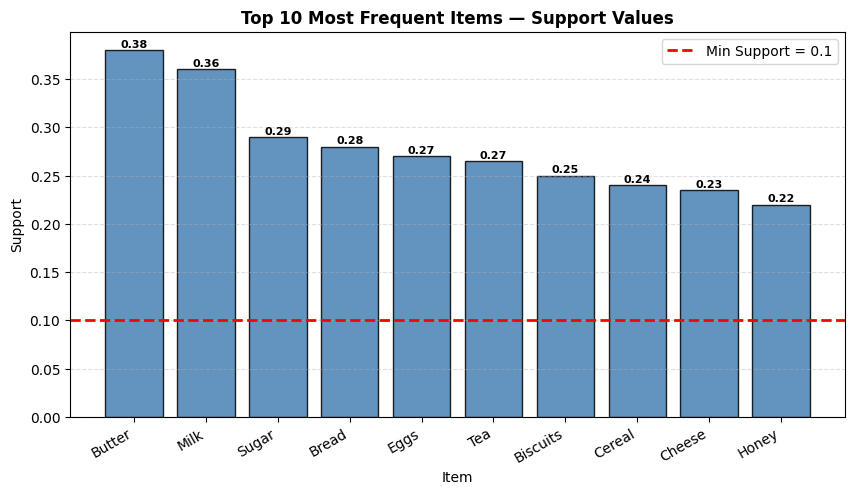

In [9]:
#  VISUALIZATIONS
# PLOT 1 : Top 10 Most Frequent Items (bar chart)
top_items = sorted(item_freq.items(), key=lambda x: -x[1])[:10]
items_names, items_counts = zip(*top_items)
item_supports = [c/n for c in items_counts]
plt.figure(figsize=(10, 5))
bars = plt.bar(items_names, item_supports,color='steelblue', edgecolor='black', alpha=0.85)
plt.axhline(MIN_SUPPORT, color='red', linestyle='--', linewidth=2, label=f'Min Support = {MIN_SUPPORT}')
for b, v in zip(bars, item_supports):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
             f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')
plt.title('Top 10 Most Frequent Items — Support Values',fontsize=12, fontweight='bold')
plt.xlabel('Item')
plt.ylabel('Support')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

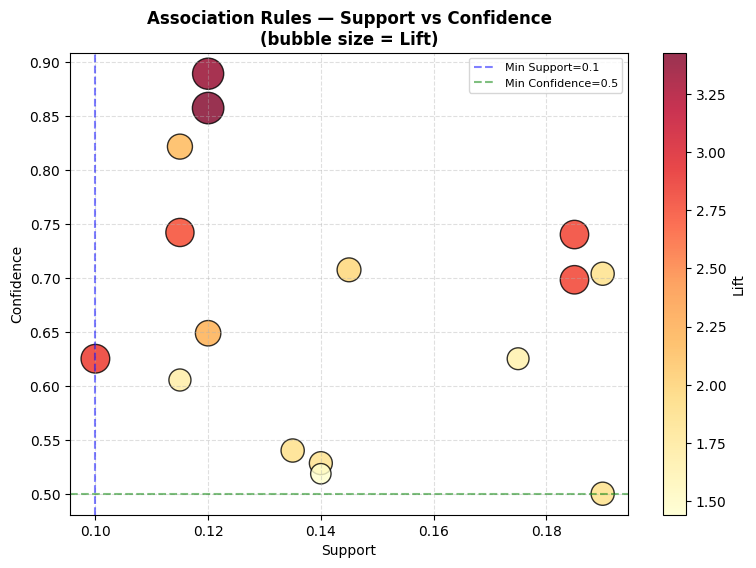

In [10]:
# PLOT 2 : Association Rules Scatter — Support vs Confidence
if rules:
    supp_vals = [r['support']    for r in rules_sorted]
    conf_vals = [r['confidence'] for r in rules_sorted]
    lift_vals = [r['lift']       for r in rules_sorted]

    plt.figure(figsize=(9, 6))
    sc = plt.scatter(supp_vals, conf_vals, s=[l * 150 for l in lift_vals],c=lift_vals, cmap='YlOrRd', edgecolors='black', alpha=0.8)
    plt.colorbar(sc, label='Lift')
    plt.axvline(MIN_SUPPORT,    color='blue',  linestyle='--', alpha=0.5, label=f'Min Support={MIN_SUPPORT}')
    plt.axhline(MIN_CONFIDENCE, color='green', linestyle='--',alpha=0.5, label=f'Min Confidence={MIN_CONFIDENCE}')
    plt.title('Association Rules — Support vs Confidence\n(bubble size = Lift)',fontsize=12, fontweight='bold')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.legend(fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.4)

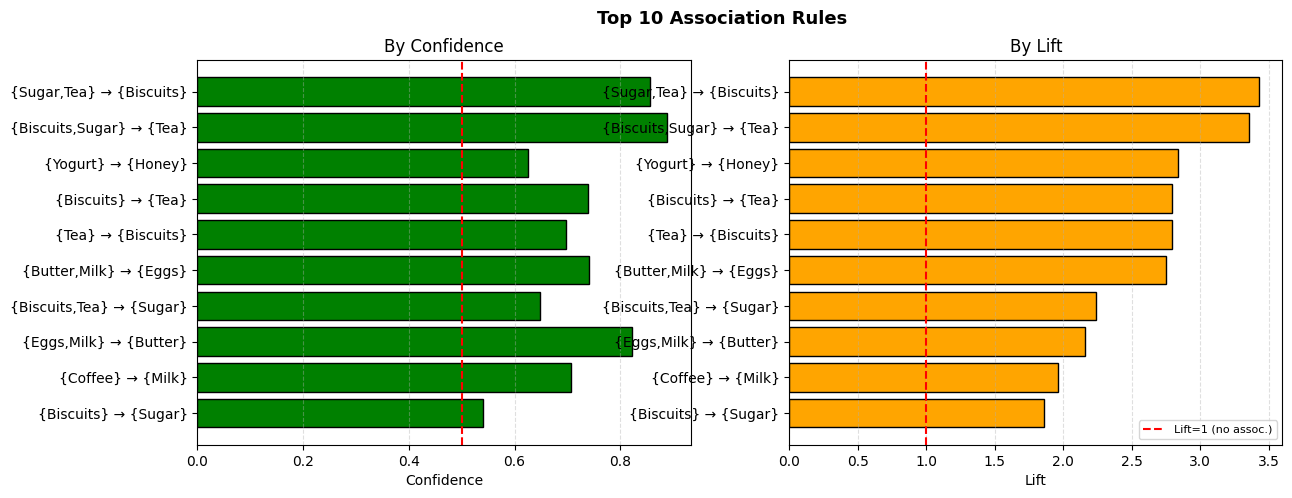

In [19]:
# PLOT 3 : Top 10 Rules by Confidence — horizontal bar
if rules:
    top10 = rules_sorted[:10]
    rule_labels = ['{' + ','.join(sorted(r['antecedent'])) + '} → {'
                   + ','.join(sorted(r['consequent'])) + '}' for r in top10]
    conf_top = [r['confidence'] for r in top10]
    lift_top = [r['lift']       for r in top10]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Top 10 Association Rules', fontsize=13, fontweight='bold')

    axes[0].barh(rule_labels[::-1], conf_top[::-1], color='green', edgecolor='black')
    axes[0].set_title('By Confidence')
    axes[0].set_xlabel('Confidence')
    axes[0].axvline(MIN_CONFIDENCE, color='red', linestyle='--')
    axes[0].grid(axis='x', linestyle='--', alpha=0.4)

    axes[1].barh(rule_labels[::-1], lift_top[::-1],color='orange', edgecolor='black')
    axes[1].set_title('By Lift')
    axes[1].set_xlabel('Lift')
    axes[1].axvline(1.0, color='red', linestyle='--', label='Lift=1 (no assoc.)')
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='x', linestyle='--', alpha=0.4)

In [20]:
#  SUMMARY
print(" SUMMARY")
print(f"  Transactions       : {n}")
print(f"  Unique Items       : {len(all_items)}")
print(f"  Min Support        : {MIN_SUPPORT}")
print(f"  Min Confidence     : {MIN_CONFIDENCE}")
print(f"  Frequent Itemsets  : {len(freq_itemsets)}")
print(f"  Association Rules  : {len(rules)}")
if rules:
    top = rules_sorted[0]
    lhs = ', '.join(sorted(top['antecedent']))
    rhs = ', '.join(sorted(top['consequent']))
    print(f"\n   Strongest Rule  : {lhs}  →  {rhs}")
    print(f"     Confidence : {top['confidence']:.2%}")
    print(f"     Lift       : {top['lift']:.3f}")
print("\n   Key Observations:")
print("  1. Lift > 1 means items are positively associated.")
print("  2. Lift = 1 means items are independent.")
print("  3. Confidence shows how often the rule is correct.")
print("  4. Support shows how common the itemset is overall.")

 SUMMARY
  Transactions       : 200
  Unique Items       : 15
  Min Support        : 0.1
  Min Confidence     : 0.5
  Frequent Itemsets  : 30
  Association Rules  : 16

   Strongest Rule  : Sugar, Tea  →  Biscuits
     Confidence : 85.71%
     Lift       : 3.429

   Key Observations:
  1. Lift > 1 means items are positively associated.
  2. Lift = 1 means items are independent.
  3. Confidence shows how often the rule is correct.
  4. Support shows how common the itemset is overall.
